In [4]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np

# PHẦN 1

## 1. Đọc dữ liệu, hiển thị 5 dòng đầu; cho biết số dòng, số cột và kiểu dữ liệu của từng cột.

In [31]:
df = sns.load_dataset("iris")
print(df.head())
print(df.shape)
print(df.dtypes)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


## 2. Với mỗi biến số, tính: mean, median, mode, var, std, min, max, Q1, Q3 và IQR.

In [32]:
numeric_cols = df.select_dtypes(include=['float64']).columns
dict = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    dict[col] = {
        'mean': df[col].mean(),
        'median': df[col].median(),
        'mode': df[col].mode()[0],
        'var': df[col].var(),
        'std': df[col].std(),
        'min': df[col].min(),
        'max': df[col].max(),
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR
    }
df_2 = pd.DataFrame(dict).T
df_2

,mean,median,mode,var,std,min,max,Q1,Q3,IQR
sepal_length,5.843333,5.80,5.0,0.685694,0.828066,4.3,7.9,5.1,6.4,1.3
sepal_width,3.057333,3.00,3.0,0.189979,0.435866,2.0,4.4,2.8,3.3,0.5
petal_length,3.758000,4.35,1.4,3.116278,1.765298,1.0,6.9,1.6,5.1,3.5
petal_width,1.199333,1.30,0.2,0.581006,0.762238,0.1,2.5,0.3,1.8,1.5


## 3. Theo từng nhóm (loài species): dùng groupby tính mean và std của từng biến. Nhận xét nhóm nào khác biệt rõ nhất.

In [33]:
species_stats = df.groupby('species').agg(['mean', 'std'])
species_stats

sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
setosa            5.006  0.352490       3.428  0.379064        1.462   
versicolor        5.936  0.516171       2.770  0.313798        4.260   
virginica         6.588  0.635880       2.974  0.322497        5.552   

                     petal_width            
                 std        mean       std  
species                                     
setosa      0.173664       0.246  0.105386  
versicolor  0.469911       1.326  0.197753  
virginica   0.551895       2.026  0.274650

Dựa vào bảng kết quả thống kê bạn vừa chạy, nhóm có sự khác biệt rõ rệt và tách biệt nhất chính là loài setosa. 
+ Chiều dài cánh hoa (petal_length) trung bình của setosa chỉ là 1.462, bằng khoảng 1/3 so với versicolor (4.26) và 1/4 so với virginica (5.55). Tương tự, chiều rộng cánh hoa (petal_width) cũng cực kỳ bé, chỉ 0.246. 
+ Nhìn vào cột std (độ lệch chuẩn) của cánh hoa, setosa có giá trị thấp nhất (chỉ 0.173 và 0.105). Điều này có nghĩa là kích thước cánh hoa của loài này rất đồng đều, ít biến động, tạo thành một cụm dữ liệu nằm tách biệt hoàn toàn.

# PHẦN 2

## 1. Vẽ histogram + KDE cho từng biến số. Nhận xét hình dạng phân phối: lệch trái/phải, gần phân phối chuẩn, hay nhiều đỉnh?

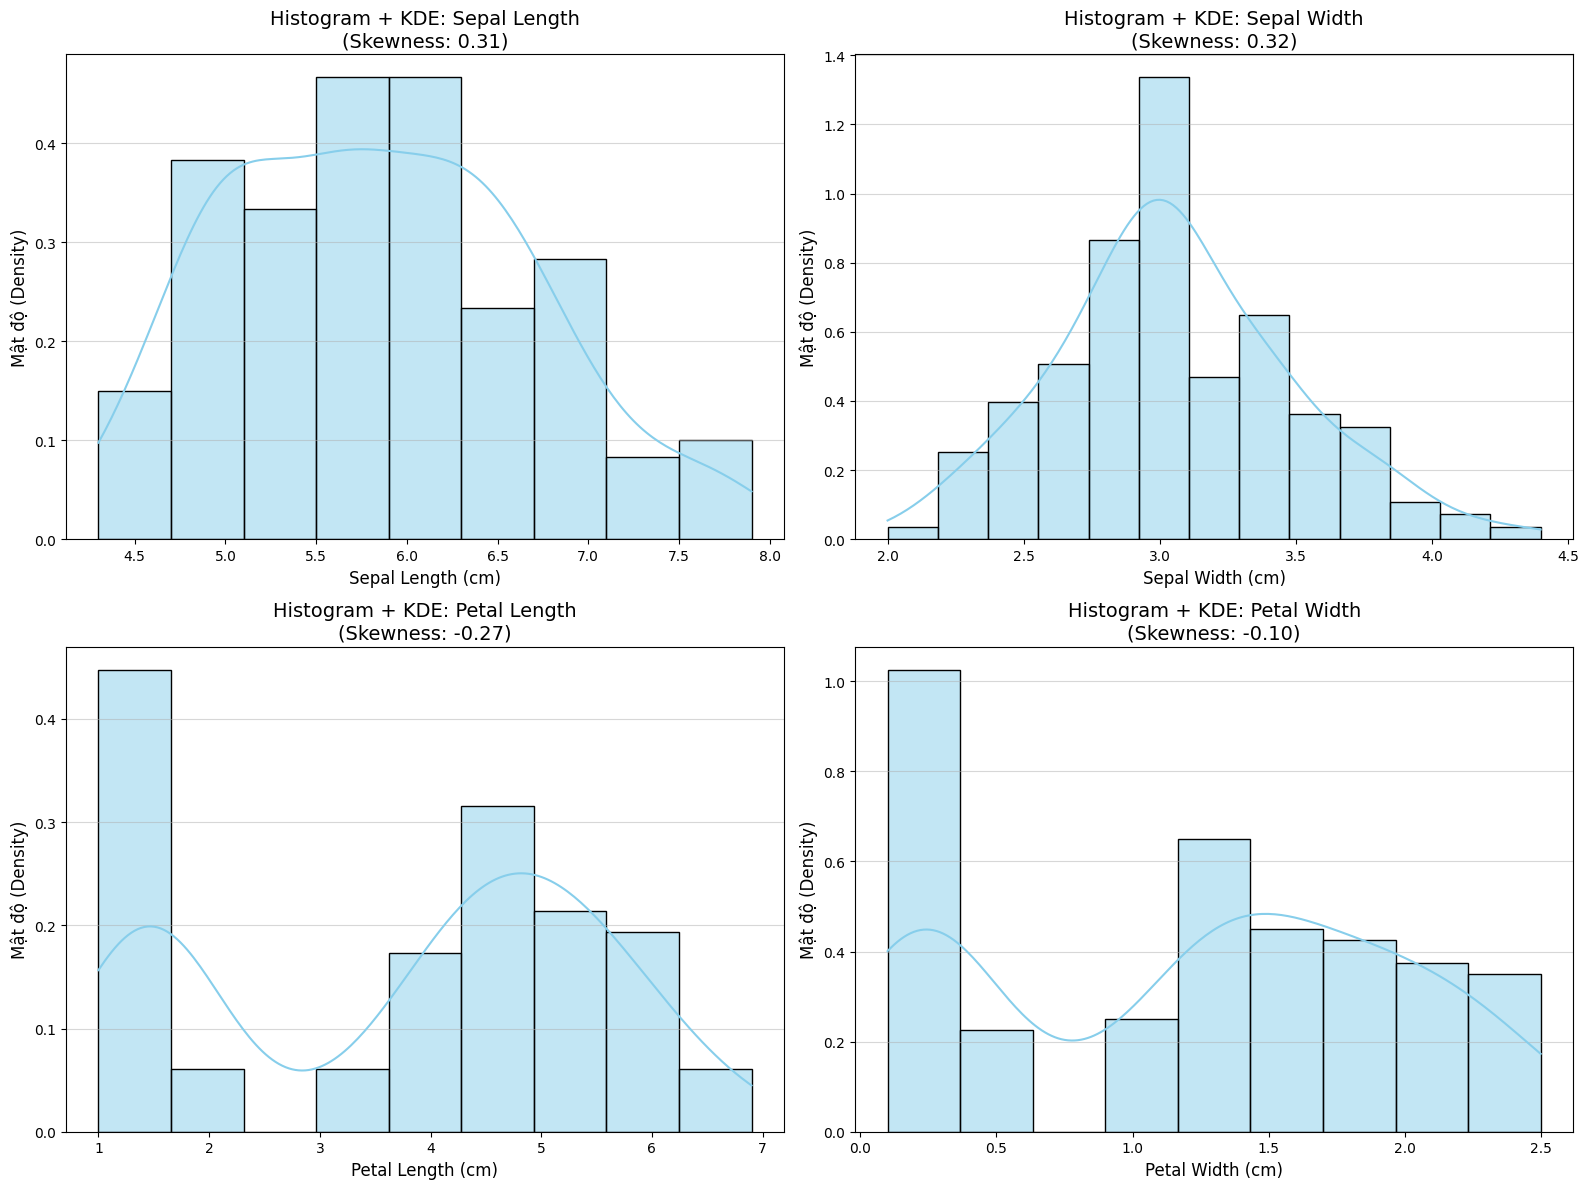

--- Giá trị Skewness cho từng biến ---
Sepal Length: 0.3149
Sepal Width: 0.3190
Petal Length: -0.2749
Petal Width: -0.1030


In [42]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten() 
for col, ax in zip(numeric_cols, axes):
    sns.histplot(data=df, x=col, kde=True, stat="density", ax=ax, bins='auto', color='skyblue')
    skewness = df[col].skew()
    ax.set_title(f'Histogram + KDE: {col.replace("_", " ").title()}\n(Skewness: {skewness:.2f})', fontsize=14)
    ax.set_xlabel(f'{col.replace("_", " ").title()} (cm)', fontsize=12)
    ax.set_ylabel('Mật độ (Density)', fontsize=12)
    ax.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()
print("--- Giá trị Skewness cho từng biến ---")
for col in numeric_cols:
    print(f"{col.replace('_', ' ').title()}: {df[col].skew():.4f}")

+ Sepal Width: Đây là biến có phân phối gần với phân phối chuẩn nhất. Đường cong KDE có hình quả chuông (bell-curve) rất mượt mà và tập trung quanh giá trị trung bình (khoảng 3.0). Độ lệch: Trực quan cho thấy nó khá đối xứng. Giá trị Skewness là 0.32 (lệch phải rất nhẹ), nhưng tổng thể vẫn là phân phối chuẩn.
+ Sepal Length: Phân phối cũng gần chuẩn nhưng phần đỉnh hơi bè (phẳng) hơn so với Sepal Width, không tạo thành hình chuông nhọn hoàn hảo. Tương tự Sepal Width, đường cong KDE cho thấy nó hơi lệch về bên phải một chút (Skewness 0.31).
+ Petal Length: Biểu đồ bị đứt gãy rõ rệt ở giữa (khoảng giá trị 2.5 - 3.5), tạo thành hai đỉnh riêng biệt.
Giải thích: Đỉnh nhỏ hẹp ở bên trái (quanh mốc 1.5) chính là cụm dữ liệu của loài setosa (như ta đã phân tích ở các bước trước là nó rất ngắn và tách biệt). Cụm đỉnh to và rộng hơn ở bên phải (từ 4.0 - 6.0) là sự gộp chung của hai loài versicolor và virginica.
Vì cụm bên phải to và chiếm nhiều dữ liệu hơn, nên phần "đuôi" của toàn bộ phân phối bị kéo dài về bên trái, dẫn đến Skewness âm (-0.27, lệch trái).
+ Petal Width: Tương tự như Petal Length, phân phối này cũng có hai đỉnh rõ rệt với một "thung lũng" ở giữa (khoảng 0.6 - 0.9).
Giải thích: Đỉnh cao chót vót sát trục tung bên trái chính là loài setosa (cánh hoa rất hẹp). Phần đồi thoai thoải bên phải là của hai loài còn lại.

## 2. Vẽ boxplot từng biến theo nhóm (species) để so sánh phân phối giữa các loài.

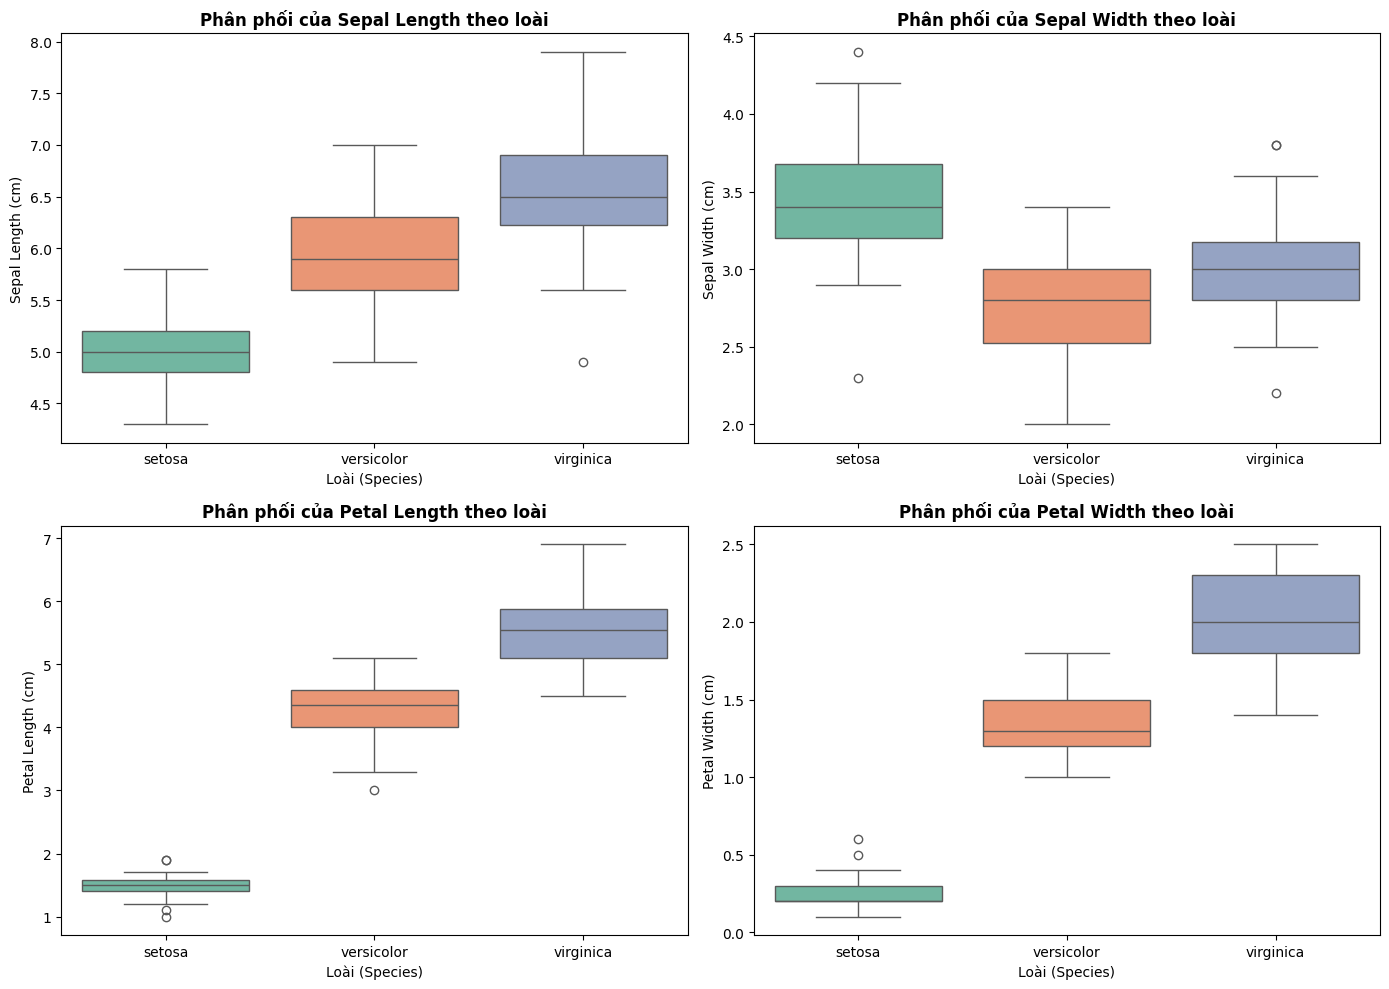

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='species', y=col, hue='species', ax=axes[i], palette='Set2', legend=False)
    axes[i].set_title(f'Phân phối của {col.replace("_", " ").title()} theo loài', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Loài (Species)', fontsize=10)
    axes[i].set_ylabel(f'{col.replace("_", " ").title()} (cm)', fontsize=10)
plt.tight_layout()
plt.show()

Nhóm Cánh hoa (Petal Length & Width):
+ Setosa: Nhỏ bé nhất và tách biệt 100%. Kích thước cánh hoa cực kỳ đồng đều và không hề trộn lẫn với hai loài kia. Chỉ cần nhìn vào cánh hoa là nhận ra ngay Setosa.
+ Versicolor & Virginica: Virginica to và dài hơn Versicolor. Dù có một khoảng nhỏ giao thoa (những bông Versicolor to nhất có thể bằng bông Virginica nhỏ nhất), nhưng nhìn chung vẫn rất dễ phân biệt.

Nhóm Đài hoa (Sepal Length & Width):
+ Kích thước đài hoa của cả 3 loài bị trộn lẫn vào nhau rất nhiều, ranh giới không rõ ràng.
+ Mặc dù cánh hoa và chiều dài đài hoa nhỏ nhất, nhưng Setosa lại là loài có chiều rộng đài hoa (Sepal Width) lớn nhất.

## 3. Mô phỏng: chọn một biến, sinh mẫu từ phân phối Normal có cùng mean và std bằng np.random.normal; vẽ chồng histogram dữ liệu thực tế với đường PDF lý  thuyết. Nhận xét mức độ khớp.

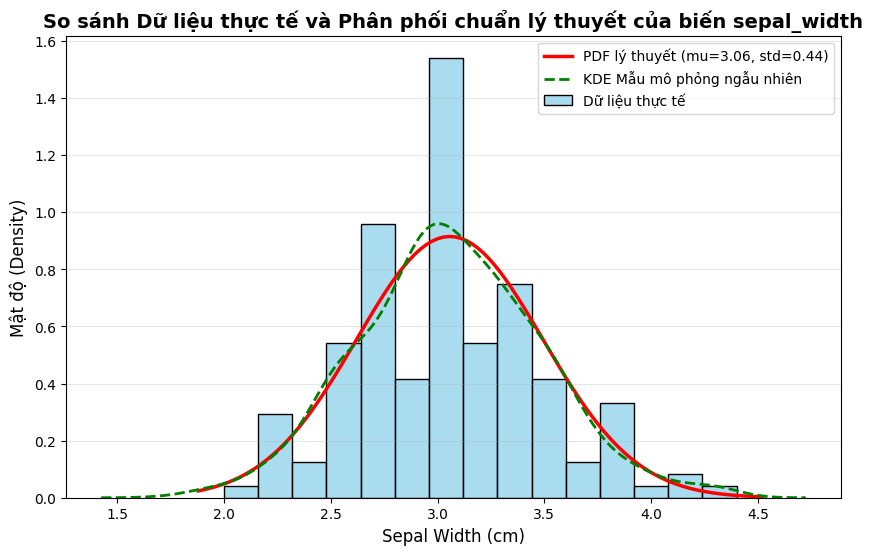

In [44]:
col = 'sepal_width'
real_data = df[col]
mu = real_data.mean()
std = real_data.std()
simulated_data = np.random.normal(mu, std, 1000)

plt.figure(figsize=(10, 6))
sns.histplot(real_data, bins=15, stat="density", color="skyblue", alpha=0.7, label="Dữ liệu thực tế")

xmin, xmax = plt.xlim()
x_pdf = np.linspace(xmin, xmax, 100) 
y_pdf = norm.pdf(x_pdf, mu, std)  

plt.plot(x_pdf, y_pdf, color="red", linewidth=2.5, label=f'PDF lý thuyết (mu={mu:.2f}, std={std:.2f})')
sns.kdeplot(simulated_data, color="green", linestyle="--", linewidth=2, label="KDE Mẫu mô phỏng ngẫu nhiên")

plt.title(f'So sánh Dữ liệu thực tế và Phân phối chuẩn lý thuyết của biến {col}', fontsize=14, fontweight='bold')
plt.xlabel('Sepal Width (cm)', fontsize=12)
plt.ylabel('Mật độ (Density)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

+ Hình dạng tổng thể: Đường PDF lý thuyết (màu đỏ) có hình dạng quả chuông đối xứng hoàn hảo, trong khi dữ liệu thực tế (histogram và đường KDE màu xanh nhạt) bám sát hình dạng này khá tốt.
+ Đỉnh của PDF lý thuyết nằm rất gần đỉnh của phân phối thực tế. Chiều cao đỉnh cũng tương đối khớp, cho thấy trung bình và độ lệch chuẩn lý thuyết nắm bắt tốt tâm điểm của dữ liệu.


# PHẦN 3

## 1. Tính ma trận hiệp phương sai (covariance) và tương quan (correlation) giữa các biến số.

In [45]:
df_numeric = df[numeric_cols]
cov_matrix = df_numeric.cov()
print(" MA TRẬN HIỆP PHƯƠNG SAI (COVARIANCE)")
print(cov_matrix)

corr_matrix = df_numeric.corr()
print(" MA TRẬN TƯƠNG QUAN (CORRELATION) ")
print(corr_matrix)

 MA TRẬN HIỆP PHƯƠNG SAI (COVARIANCE)
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006
 MA TRẬN TƯƠNG QUAN (CORRELATION) 
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


# 2. Vẽ heatmap tương quan; nhận xét cặp biến tương quan mạnh nhất. Có dấu hiệu đa cộng tuyến không?

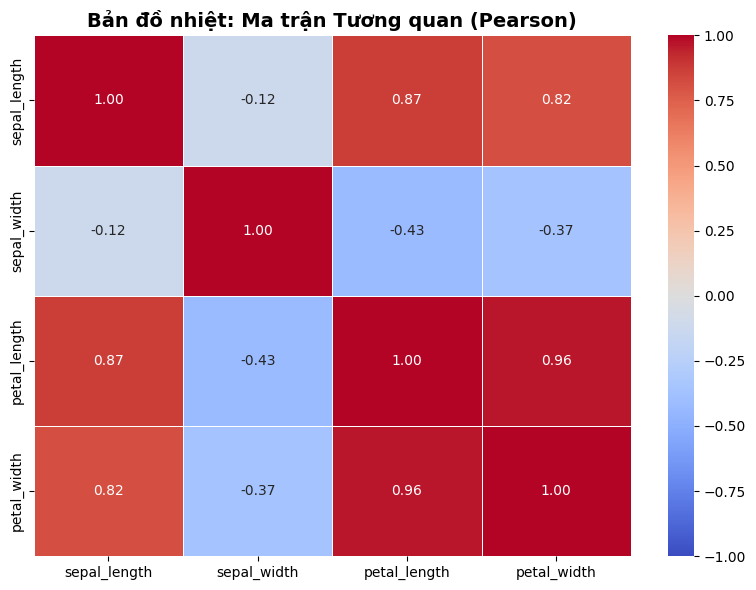

In [46]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Bản đồ nhiệt: Ma trận Tương quan (Pearson)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Cặp biến có hệ số tương quan cao nhất là: petal_length (Chiều dài cánh hoa) và petal_width (Chiều rộng cánh hoa) với hệ số lên tới 0.96.
Có dấu hiệu đa cộng tuyến vì có tới 3 cặp biến có hệ số tương quan rất cao:
+ petal_length và petal_width (0.96)
+ sepal_length và petal_length (0.87)
+ sepal_length và petal_width (0.82)

## 3. Vẽ pairplot (hoặc scatter theo cặp), tô màu theo species; nhận xét quan hệ giữa các biến.

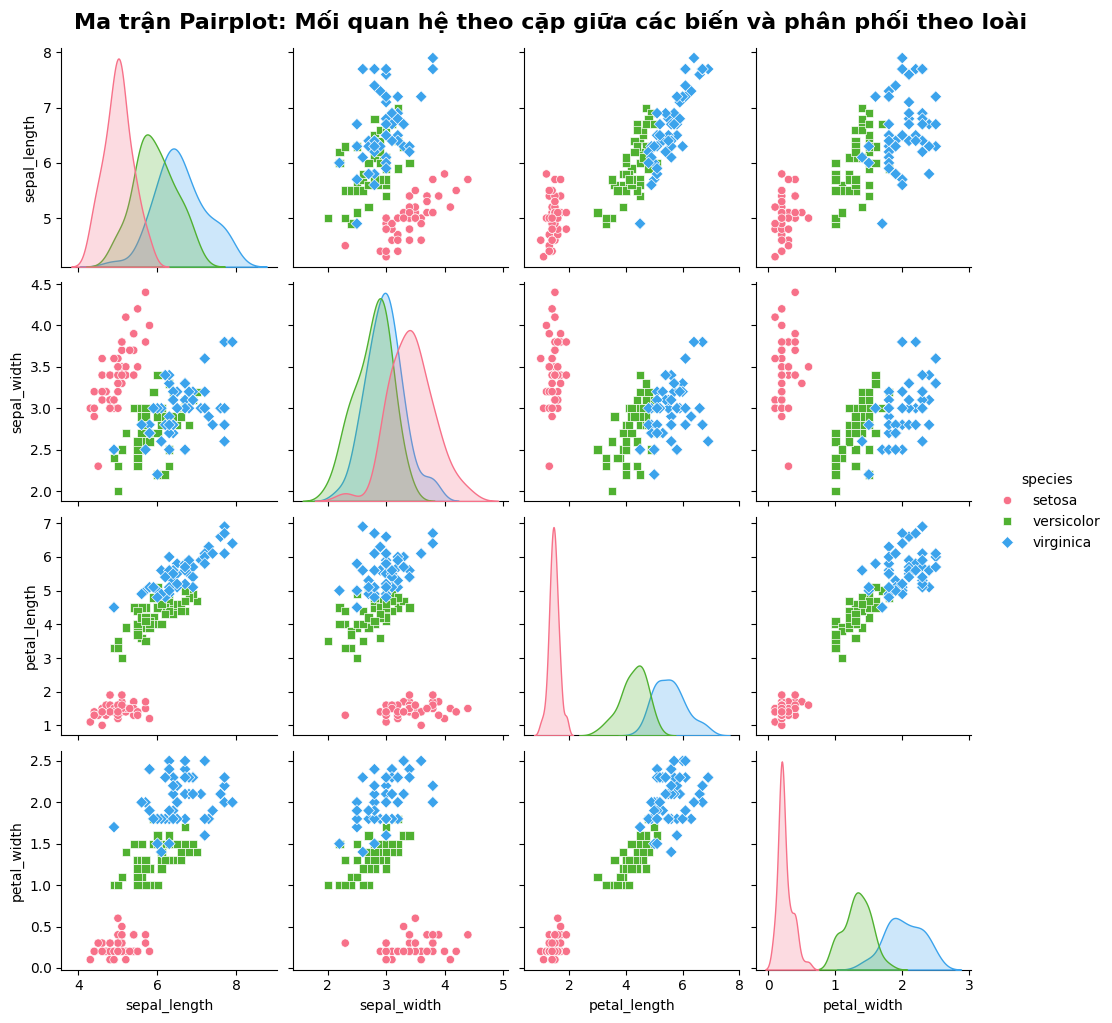

In [47]:
sns.pairplot(df, hue='species', diag_kind='kde', palette='husl', markers=["o", "s", "D"])
plt.suptitle('Ma trận Pairplot: Mối quan hệ theo cặp giữa các biến và phân phối theo loài', y=1.02, fontsize=16, fontweight='bold')

plt.show()

+ Nhóm Cánh hoa (Petal): Chiều dài (Petal Length) và Chiều rộng cánh hoa (Petal Width) là 2 đặc điểm tốt nhất để phân loại các loài hoa. Hai biến này có tương quan thuận cực kỳ mạnh (0.96). Nếu dùng để huấn luyện mô hình, chúng mang thông tin trùng lặp nhiều, có thể chỉ cần giữ lại 1 biến là đủ.
+ Loài Setosa: Dễ dàng nhận diện ngay lập tức. Cánh hoa của nó siêu nhỏ và tạo thành một cụm riêng biệt hoàn toàn. Có đài hoa ngắn nhất nhưng lại rộng nhất.
Chính vì Setosa quá nhỏ và tách biệt nên biểu đồ phân phối của nhóm Cánh hoa bị đứt gãy, tạo thành phân phối 2 đỉnh (Bimodal) thay vì hình chuông.

# PHẦN 4

## 1. Viết code tính xác suất hậu nghiệm P(B | +) bằng định lý Bayes và in kết quả

In [ ]:
P_B = 0.01          
P_pos_givenB = 0.99 
P_pos_givenNB = 0.05 

P_NB = 1 - P_B

P_pos = (P_pos_givenB * P_B) + (P_pos_givenNB * P_NB)

P_B_given_pos = (P_pos_givenB * P_B) / P_pos

print(f"Xác suất mắc bệnh nếu xét nghiệm dương tính là: {P_B_given_pos:.4f} (khoảng {P_B_given_pos*100:.2f}%)")

Xác suất mắc bệnh nếu xét nghiệm dương tính là: 0.1667 (khoảng 16.67%)


## 2. Khảo sát: vẽ đồ thị P(B | +) khi tỉ lệ mắc bệnh P(B) thay đổi từ 0.001 đến 0.2. Giải thích vì sao khi bệnh hiếm, kết quả lại "phản trực giác".

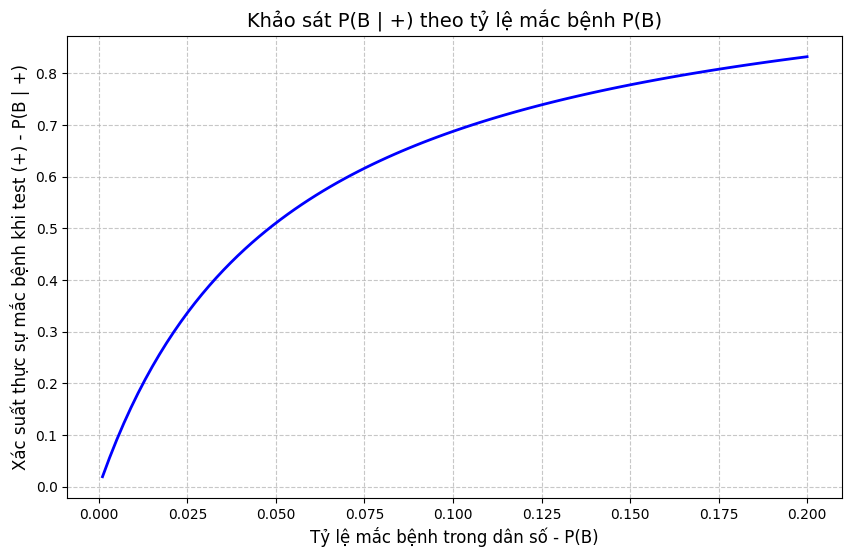

In [49]:
P_B_array = np.linspace(0.001, 0.2, 100)

P_pos_givenB = 0.99
P_pos_givenNB = 0.05

# Hàm tính P(B | +)
def calculate_posterior(p_b, tpr, fpr):
    p_pos = (tpr * p_b) + (fpr * (1 - p_b))
    return (tpr * p_b) / p_pos

P_B_given_pos_array = calculate_posterior(P_B_array, P_pos_givenB, P_pos_givenNB)

plt.figure(figsize=(10, 6))
plt.plot(P_B_array, P_B_given_pos_array, color='blue', linewidth=2)
plt.title('Khảo sát P(B | +) theo tỷ lệ mắc bệnh P(B)', fontsize=14)
plt.xlabel('Tỷ lệ mắc bệnh trong dân số - P(B)', fontsize=12)
plt.ylabel('Xác suất thực sự mắc bệnh khi test (+) - P(B | +)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

+ Khi bệnh rất hiếm: Phần lớn kết quả Dương tính chỉ là "báo động giả". Xác suất bạn thực sự mắc bệnh là rất thấp.
+ Khi bệnh phổ biến (tỷ lệ nền cao): Lúc này số người bệnh đủ lớn để lấn át đi phần sai số của máy móc, và tờ kết quả Dương tính mới thực sự đáng tin cậy đúng như những gì bạn kỳ vọng.